# 🔑 Part 0: Google Cloud Authentication
Run this first. Click through the Google permissions popup.

In [2]:
from google.colab import auth
auth.authenticate_user()
print("✅ Authenticated.")

✅ Authenticated.


# ⚡ Part 1: Install Dependencies
albumentations gives us elastic deformation, speckle simulation, and rotation/scale.
segmentation-models-pytorch gives U-Net + backbone zoo.

In [3]:
!pip install -q segmentation-models-pytorch rasterio albumentations
import albumentations as A
print("✅ Dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.9 MB/s eta 0:00:00
✅ Dependencies installed.


# 🌩️ Part 2: Download Sen1Floods11 Dataset

In [4]:
!mkdir -p /content/sen1floods11/HandLabeled
!gcloud storage cp -r gs://sen1floods11/v1.1/data/flood_events/HandLabeled/* /content/sen1floods11/HandLabeled/

Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/JRCWaterHand/Bolivia_103757_JRCWaterHand.tif to file:///content/sen1floods11/HandLabeled/JRCWaterHand/Bolivia_103757_JRCWaterHand.tif
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/JRCWaterHand/Bolivia_129334_JRCWaterHand.tif to file:///content/sen1floods11/HandLabeled/JRCWaterHand/Bolivia_129334_JRCWaterHand.tif
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/JRCWaterHand/Bolivia_195474_JRCWaterHand.tif to file:///content/sen1floods11/HandLabeled/JRCWaterHand/Bolivia_195474_JRCWaterHand.tif
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/JRCWaterHand/Bolivia_23014_JRCWaterHand.tif to file:///content/sen1floods11/HandLabeled/JRCWaterHand/Bolivia_23014_JRCWaterHand.tif
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/JRCWaterHand/Bolivia_233925_JRCWaterHand.tif to file:///content/sen1floods11/HandLabeled/JRCWaterHand/Bolivia_233925_JRCWaterHand.tif
Copying gs://sen1floods11/v

# 📦 Part 3: Imports & GPU Check

In [5]:
import os, glob, random
import torch
import rasterio
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
import segmentation_models_pytorch as smp
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Running on: {device}")

🔥 Running on: cuda


# 📊 Part 4: Augmentation Pipeline

**v3 augmentations (vs v2 which only had h/v flips):**

| Augmentation | Why it helps for SAR flood mapping |
|---|---|
| HorizontalFlip / VerticalFlip | Basic orientation invariance |
| Rotate (±30°) | Flood shapes are irregular — rotation teaches texture, not just orientation |
| RandomScale (0.8–1.2) | Floods appear at different spatial scales |
| ElasticTransform | Deforms flood boundaries realistically — SAR flood edges are never perfectly sharp |
| GaussNoise | Simulates SAR speckle noise (SAR has multiplicative noise, not additive Gaussian, but this is a reasonable approximation) |
| RandomBrightnessContrast | Simulates variation in incidence angle and scene moisture across different acquisitions |

All transforms applied identically to both image and mask (albumentations handles this automatically via `additional_targets`).

In [6]:
# Augmentation pipeline — applied to TRAINING set only
# RandomScale changes spatial dimensions, so we always crop/pad back to
# a fixed size (512x512) at the end so batches can be stacked.
TARGET_SIZE = 512

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5, border_mode=0),
    A.RandomScale(scale_limit=0.2, p=0.4),      # zoom 80-120%
    # After scaling, images may be different sizes — pad then crop to TARGET_SIZE
    A.PadIfNeeded(min_height=TARGET_SIZE, min_width=TARGET_SIZE,
                  border_mode=0, value=0, mask_value=0),
    A.RandomCrop(height=TARGET_SIZE, width=TARGET_SIZE),
    A.ElasticTransform(
        alpha=1, sigma=10, p=0.3
    ),
    A.GaussNoise(std_range=(0.01, 0.05), p=0.4),  # speckle approximation
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
], additional_targets={"mask": "mask"}, is_check_shapes=False)

print(f"✅ Augmentation pipeline defined. Output size: {TARGET_SIZE}x{TARGET_SIZE}")

✅ Augmentation pipeline defined. Output size: 512x512


/tmp/ipykernel_904/791677783.py:12: UserWarning: Argument(s) 'value, mask_value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=TARGET_SIZE, min_width=TARGET_SIZE,


# 📂 Part 5: Dataset with 72 / 18 / 10 Split

In [13]:
class Sen1FloodsDataset(Dataset):
    """Base dataset loads and preprocesses, NO augmentation."""
    def __init__(self, data_dir):
        self.image_paths = sorted(glob.glob(
            os.path.join(data_dir, "**", "*_S1Hand.tif"), recursive=True
        ))
        self.mask_paths = [
            p.replace("S1Hand", "LabelHand") for p in self.image_paths
        ]
        # ADDED: Load the JRC Water Mask paths
        self.jrc_paths = [
            p.replace("S1Hand", "JRCWaterHand") for p in self.image_paths
        ]
        print(f" Found {len(self.image_paths)} image/mask pairs.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 1. Load SAR Image (VV and VH) using rasterio
        with rasterio.open(self.image_paths[idx]) as src:
            image = src.read().astype(np.float32)
            image = np.nan_to_num(image)
            image = np.clip(image, -30, 0)
            image = (image + 30) / 30.0  # Normalizes to 0-1 range

        vv = image[0]
        vh = image[1]

        # 2. Create Ratio Channel
        epsilon = 1e-7
        ratio = vv / (vh + epsilon)
        ratio = (ratio - ratio.min()) / (ratio.max() - ratio.min() + epsilon)

        # 3. Load JRC Permanent Water Mask using rasterio
        with rasterio.open(self.jrc_paths[idx]) as src:
            jrc_water = src.read(1).astype(np.float32)
            jrc_water = np.clip(jrc_water, 0, 1)

        # 4. Stack all 4 channels together
        image_4ch = np.stack([vv, vh, ratio, jrc_water], axis=0) # Shape: (4, H, W)

        # 5. Load label mask
        with rasterio.open(self.mask_paths[idx]) as src:
            mask = src.read(1).astype(np.float32)
            mask = np.where(mask == 1, 1.0, 0.0)

        image_tensor = torch.tensor(image_4ch, dtype=torch.float32)
        mask_tensor = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image_tensor, mask_tensor


class AugmentedSubset(Dataset):
    """Wraps a Subset and applies albumentations transforms on the fly.
    albumentations expects HWC for images, HW for masks.
    """
    def __init__(self, subset, transform=None):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, mask = self.subset[idx]          # tensors: (2,H,W), (1,H,W)
        if self.transform is not None:
            # albumentations needs numpy HWC / HW
            img_np  = image.numpy().transpose(1, 2, 0)   # (H,W,2)
            mask_np = mask.numpy().squeeze(0)             # (H,W)
            aug = self.transform(image=img_np, mask=mask_np)
            image = torch.tensor(
                aug["image"].transpose(2, 0, 1), dtype=torch.float32
            )  # back to (2,H,W)
            mask = torch.tensor(
                aug["mask"], dtype=torch.float32
            ).unsqueeze(0)  # back to (1,H,W)
        return image, mask


# ── Split ────────────────────────────────────────────────────────────────────
full_dataset = Sen1FloodsDataset("/content/sen1floods11/HandLabeled/")

total      = len(full_dataset)
test_size  = int(0.10 * total)
val_size   = int(0.18 * total)
train_size = total - test_size - val_size

train_base, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_dataset = AugmentedSubset(train_base, transform=train_transform)
val_aug       = AugmentedSubset(val_dataset,  transform=None)   # no aug on val
test_aug      = AugmentedSubset(test_dataset, transform=None)   # no aug on test

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_aug,       batch_size=4, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_aug,      batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset)} | Val: {len(val_aug)} | Test: {len(test_aug)}")

 Found 446 image/mask pairs.
Train: 322 | Val: 80 | Test: 44


# 🧠 Part 6: Model — EfficientNet-B3 backbone

**v3 backbone change: ResNet34 → EfficientNet-B3**

| Backbone | Params | ImageNet top-1 | Notes |
|---|---|---|---|
| ResNet34 | 21M | 73.3% | v1 + v2 baseline |
| ResNet50 | 25M | 76.1% | Better but heavy |
| EfficientNet-B3 | 12M | 81.6% | **Fewer params, significantly better feature extraction** |

EfficientNet was designed with compound scaling (width + depth + resolution together)
which gives it much richer multi-scale feature maps — critical for SAR segmentation
where flood boundaries appear at many scales simultaneously.
Same U-Net decoder, just swap `encoder_name`.

In [14]:
model = smp.Unet(
    encoder_name="efficientnet-b3",
    encoder_weights="imagenet",  # <-- CHANGE THIS
    in_channels=4,               # <-- CHANGE THIS
    classes=1,
    activation=None
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model: U-Net + EfficientNet-B3  |  Trainable params: {total_params:,}")

✅ Model: U-Net + EfficientNet-B3  |  Trainable params: 13,159,393


# ⚖️ Part 7: Loss Function — Dice + Focal Loss

**v3 loss change: SoftBCE → Focal Loss**

`pos_weight=10` in BCE is a blunt instrument — it multiplies the loss for ALL
flood pixels equally regardless of how easy or hard they are to predict.

**Focal Loss** solves this properly:
- Easy pixels (model already confident) → loss weight close to 0
- Hard pixels (model uncertain, near boundary) → loss weight stays high
- Automatically focuses training on the pixels that matter most
- `gamma=2` is the standard setting from the original paper (Lin et al. 2017)
- `alpha=0.75` upweights the flood class (minority class in SAR data)

Combined: `DiceLoss + FocalLoss` = overlap maximisation + hard-pixel focus

In [15]:
dice_loss  = smp.losses.DiceLoss(mode="binary")
focal_loss = smp.losses.FocalLoss(
    mode="binary",
    alpha=0.75,    # upweight flood class (minority class)
    gamma=2.0,     # focus on hard/uncertain pixels
)

def criterion(outputs, masks):
    return dice_loss(outputs, masks) + focal_loss(outputs, masks)

# Lower starting LR (0.00005 vs 0.0001 in v2) — reduces val metric noise
optimizer = optim.Adam(model.parameters(), lr=0.00005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=4, factor=0.5
)

print("✅ Loss: DiceLoss + FocalLoss(alpha=0.75, gamma=2)")
print("✅ Optimizer: Adam lr=0.00005")

✅ Loss: DiceLoss + FocalLoss(alpha=0.75, gamma=2)
✅ Optimizer: Adam lr=0.00005


# 📈 Part 8: Metric Helpers

In [16]:
def iou_score(pred, target, threshold=0.5):
    pred = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

def dice_score(pred, target, threshold=0.5):
    pred = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum()
    return (2 * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)

print("✅ Metrics ready.")

✅ Metrics ready.


# 🚀 Part 9: Training Loop — 50 Epochs

v3 trains for 50 epochs (was 30). The v2 training loss was still declining at
epoch 30, meaning the model had not converged. 50 epochs with the lower LR
(0.00005) should reach a stable minimum.

In [17]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

def train_model(model, train_loader, val_loader, epochs=50):
    print("🚀 Starting v3 training...")
    best_val_loss = float("inf")
    history = []

    # --> INITIALIZE IT HERE <--
    early_stopper = EarlyStopping(patience=7, min_delta=0.005)

    for epoch in range(epochs):

        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        t_loss = t_iou = t_dice = 0.0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
            t_iou  += iou_score(outputs, masks).item()
            t_dice += dice_score(outputs, masks).item()
        n_tr = len(train_loader)

        # ── Validate ──────────────────────────────────────────────────────────
        model.eval()
        v_loss = v_iou = v_dice = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                v_loss += criterion(outputs, masks).item()
                v_iou  += iou_score(outputs, masks).item()
                v_dice += dice_score(outputs, masks).item()
        n_val = len(val_loader)
        avg_val_loss = v_loss / n_val
        scheduler.step(avg_val_loss)

        tag = ""
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "/content/flood_unet_resnet34_best.pth")
            tag = "  ⭐ BEST SAVED"

        lr = optimizer.param_groups[0]["lr"]
        row = dict(
            epoch=epoch+1,
            train_loss=t_loss/n_tr, train_iou=t_iou/n_tr, train_dice=t_dice/n_tr,
            val_loss=avg_val_loss,  val_iou=v_iou/n_val,   val_dice=v_dice/n_val,
            lr=lr
        )
        history.append(row)

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {t_loss/n_tr:.4f} | "
            f"Train IoU: {t_iou/n_tr:.4f} | Train Dice: {t_dice/n_tr:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val IoU: {v_iou/n_val:.4f} | Val Dice: {v_dice/n_val:.4f} | "
            f"LR: {lr:.6f}{tag}"
        )

        # --> CALL IT HERE AT THE END OF THE LOOP <--
        early_stopper(avg_val_loss)
        if early_stopper.early_stop:
            print("🛑 Early stopping triggered! Model has converged.")
            break

    print(f"\n✅ Done. Best val loss: {best_val_loss:.4f}")
    return history

history = train_model(model, train_loader, val_loader, epochs=50)

🚀 Starting v3 training...
Epoch 01/50 | Train Loss: 0.8884 | Train IoU: 0.1478 | Train Dice: 0.2377 | Val Loss: 0.8474 | Val IoU: 0.2235 | Val Dice: 0.3252 | LR: 0.000050  ⭐ BEST SAVED
Epoch 02/50 | Train Loss: 0.8431 | Train IoU: 0.2350 | Train Dice: 0.3382 | Val Loss: 0.8194 | Val IoU: 0.2518 | Val Dice: 0.3560 | LR: 0.000050  ⭐ BEST SAVED
Epoch 03/50 | Train Loss: 0.8010 | Train IoU: 0.3014 | Train Dice: 0.4165 | Val Loss: 0.7591 | Val IoU: 0.3752 | Val Dice: 0.5063 | LR: 0.000050  ⭐ BEST SAVED
Epoch 04/50 | Train Loss: 0.7798 | Train IoU: 0.3155 | Train Dice: 0.4365 | Val Loss: 0.6973 | Val IoU: 0.4933 | Val Dice: 0.6333 | LR: 0.000050  ⭐ BEST SAVED
Epoch 05/50 | Train Loss: 0.7449 | Train IoU: 0.3474 | Train Dice: 0.4699 | Val Loss: 0.6501 | Val IoU: 0.5223 | Val Dice: 0.6609 | LR: 0.000050  ⭐ BEST SAVED
Epoch 06/50 | Train Loss: 0.7138 | Train IoU: 0.3777 | Train Dice: 0.5051 | Val Loss: 0.6112 | Val IoU: 0.5227 | Val Dice: 0.6620 | LR: 0.000050  ⭐ BEST SAVED
Epoch 07/50 | Train 

# 📉 Part 10: Plot Training Curves

Visualise val IoU over epochs to check convergence and noise level.
A good v3 run should show val IoU climbing smoothly to >0.60 and
not swinging ±0.05 between consecutive epochs.

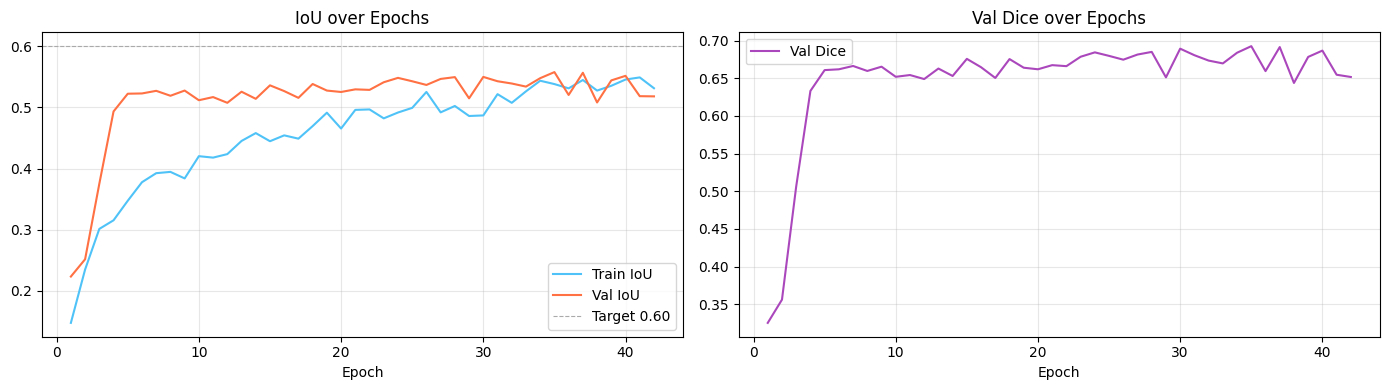

In [18]:
epochs_list = [r["epoch"]     for r in history]
val_iou     = [r["val_iou"]   for r in history]
train_iou   = [r["train_iou"] for r in history]
val_dice    = [r["val_dice"]  for r in history]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs_list, train_iou, label="Train IoU", color="#4fc3f7")
axes[0].plot(epochs_list, val_iou,   label="Val IoU",   color="#ff7043")
axes[0].axhline(0.60, color="#aaa", linestyle="--", linewidth=0.8, label="Target 0.60")
axes[0].set_title("IoU over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_list, val_dice, label="Val Dice", color="#ab47bc")
axes[1].set_title("Val Dice over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 🎯 Part 11: Final Test Set Evaluation

Load the best checkpoint and evaluate on the **held-out 10% test set**.
These are the only numbers you report in your paper/presentation.
They were never seen during training or scheduler tuning.

In [19]:
def predict_with_tta(model, image_tensor):
    """
    Applies Test-Time Augmentation by averaging predictions from
    the original image, a horizontal flip, and a vertical flip.
    """
    model.eval()
    with torch.no_grad():
        # 1. Normal prediction
        pred_normal = model(image_tensor)

        # 2. Horizontal flip prediction
        img_hflip = torch.flip(image_tensor, dims=[3])
        pred_hflip = torch.flip(model(img_hflip), dims=[3])

        # 3. Vertical flip prediction
        img_vflip = torch.flip(image_tensor, dims=[2])
        pred_vflip = torch.flip(model(img_vflip), dims=[2])

        # Average the predictions
        avg_pred = (pred_normal + pred_hflip + pred_vflip) / 3.0
        return avg_pred

model.load_state_dict(torch.load("/content/flood_unet_resnet34_best.pth", map_location=device))
model.eval()

test_iou = test_dice = 0.0
with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = predict_with_tta(model, images)
        test_iou  += iou_score(outputs, masks).item()
        test_dice += dice_score(outputs, masks).item()

n_test = len(test_loader)
print("=" * 55)
print(f"  FINAL TEST SET RESULTS  ({len(test_aug)} held-out samples)")
print(f"  Test IoU  : {test_iou  / n_test:.4f}")
print(f"  Test Dice : {test_dice / n_test:.4f}")
print("=" * 55)
print("  Record these numbers in PROJECT_NOTES.md")

  FINAL TEST SET RESULTS  (44 held-out samples)
  Test IoU  : 0.5142
  Test Dice : 0.6572
  Record these numbers in PROJECT_NOTES.md


# 📸 Part 12: Visualize Predictions

--- Sample 5 ---


/tmp/ipykernel_904/3772653808.py:12: UserWarning: Glyph 128225 (\N{SATELLITE ANTENNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_904/3772653808.py:12: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_904/3772653808.py:12: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128225 (\N{SATELLITE ANTENNA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.pri

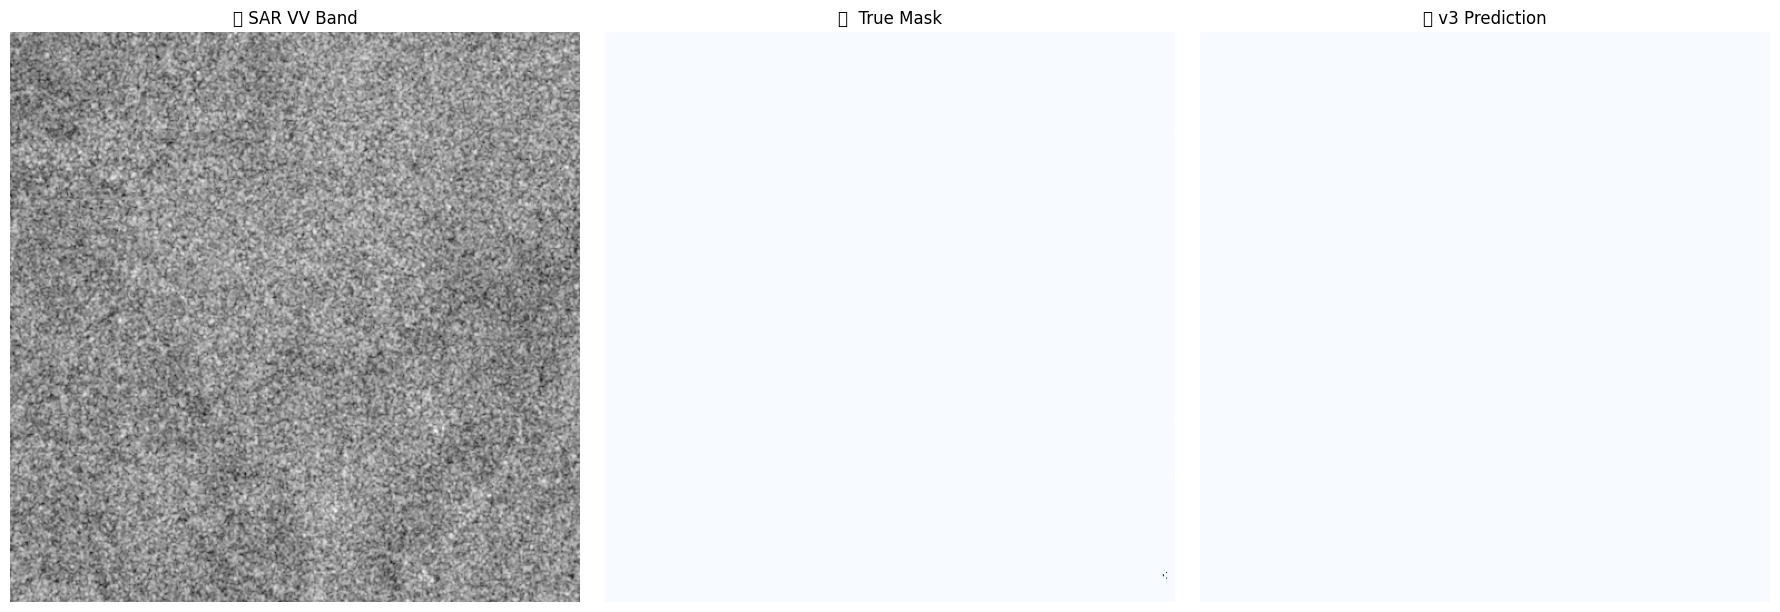

--- Sample 10 ---


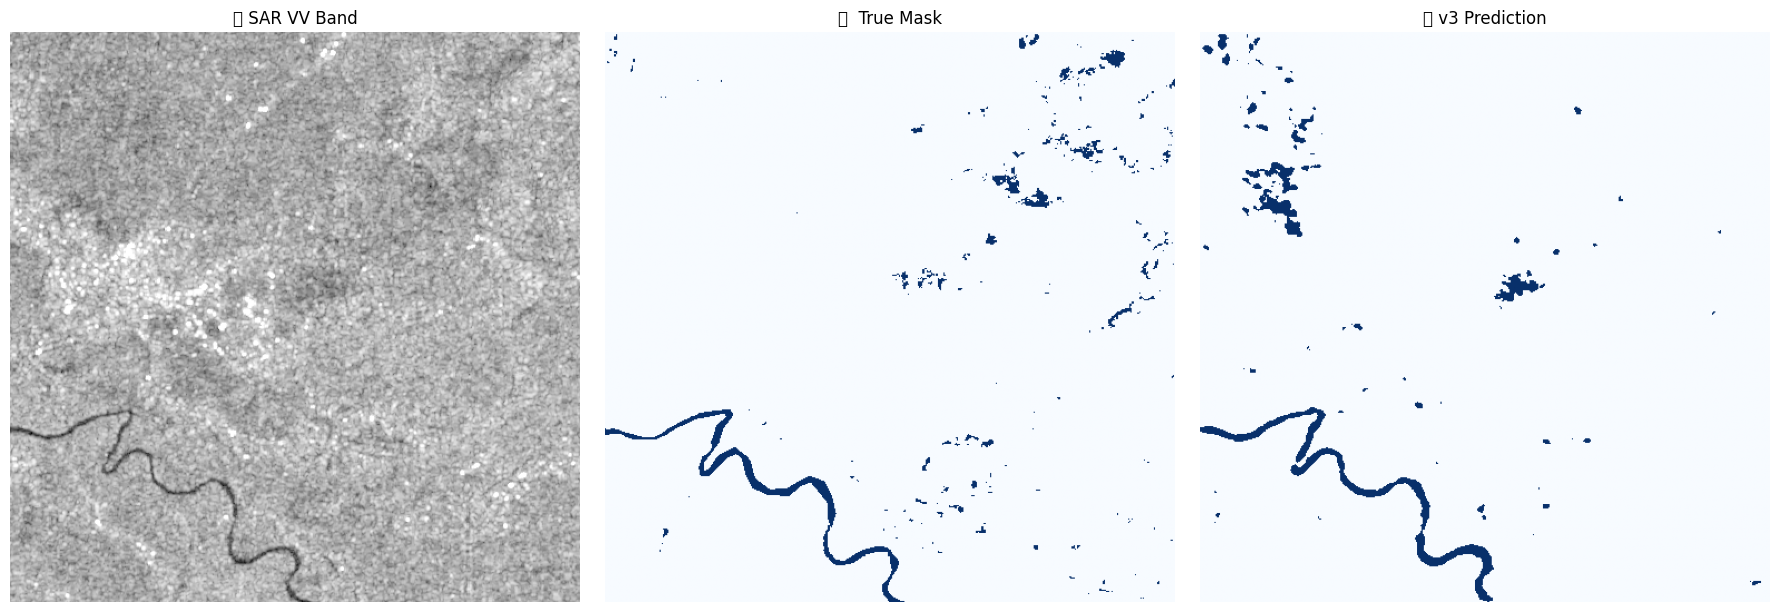

--- Sample 15 ---


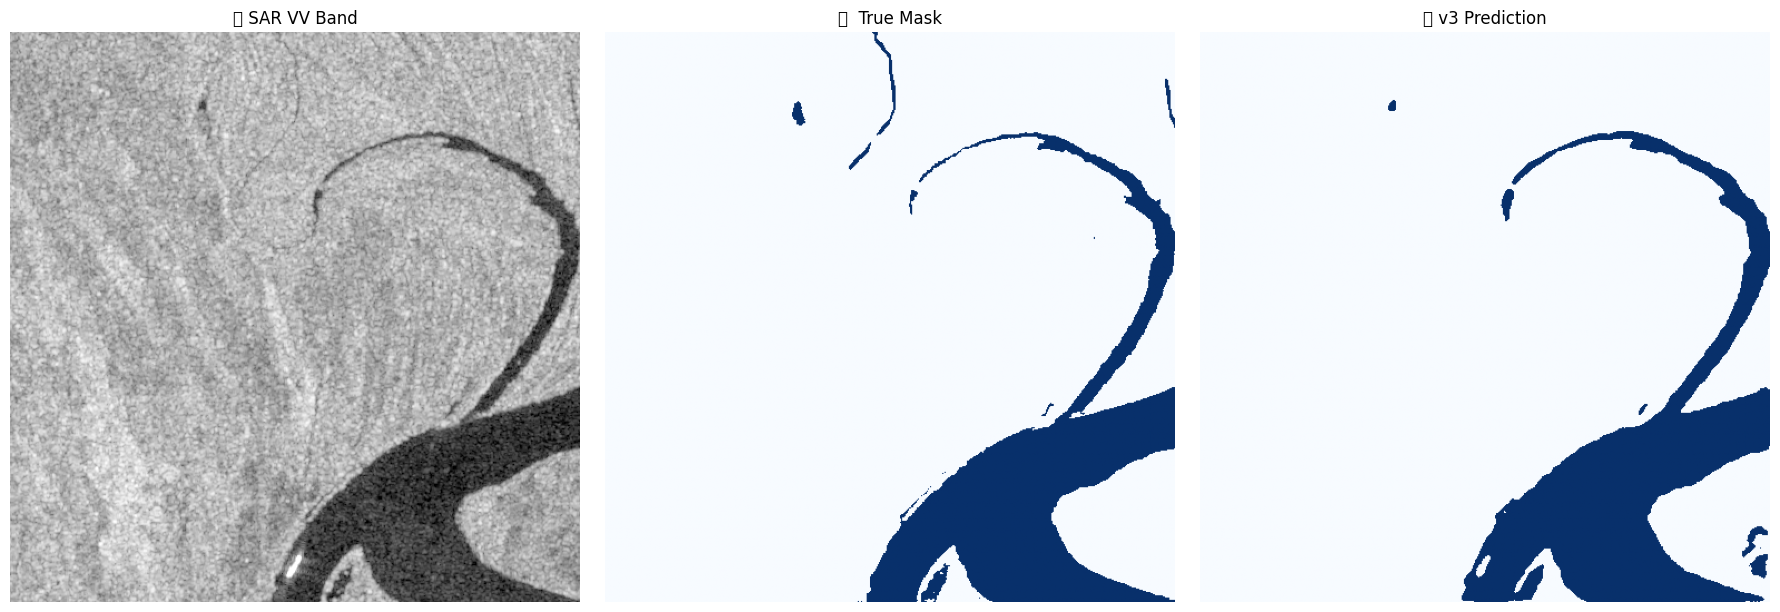

--- Sample 20 ---


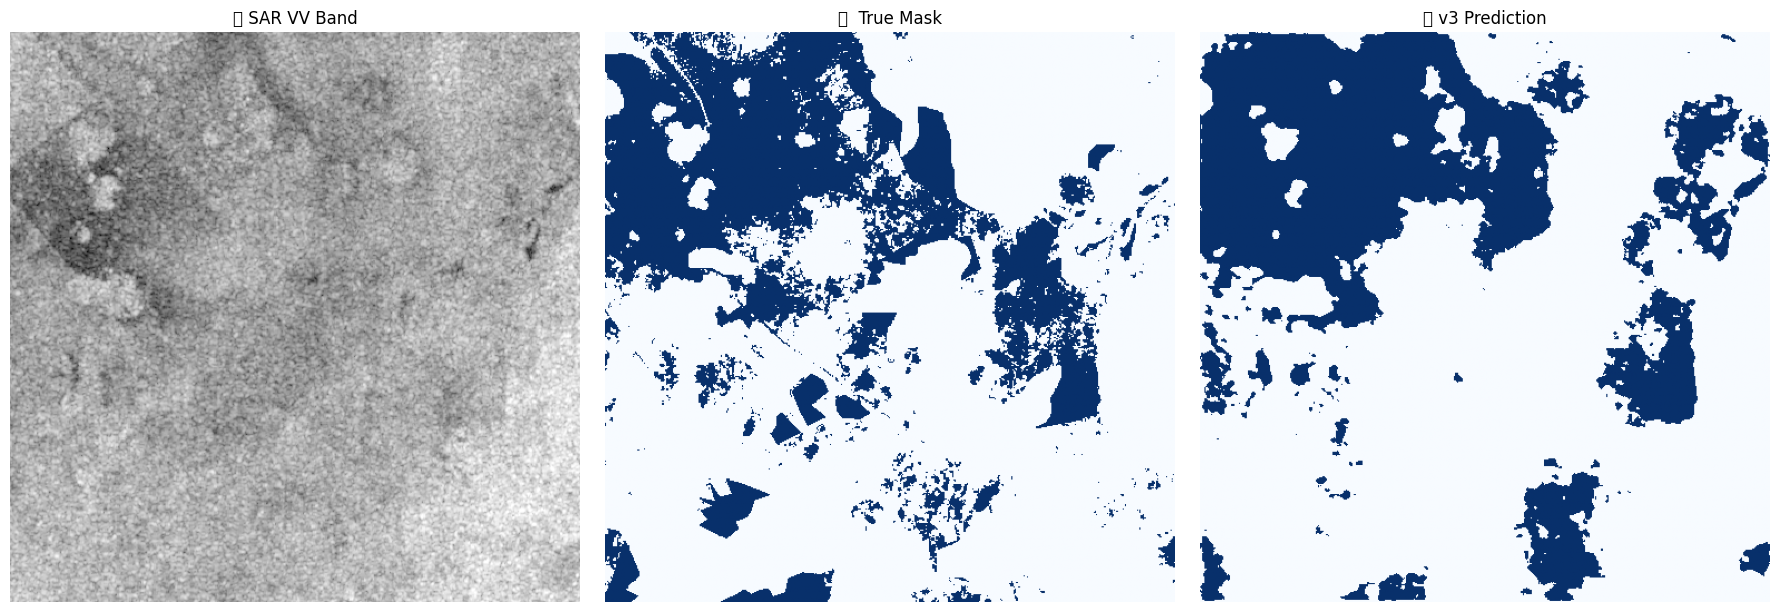

In [20]:
def visualize_prediction(model, dataset, index=0):
    model.eval()
    image, true_mask = dataset[index]
    with torch.no_grad():
        pred = torch.sigmoid(model(image.unsqueeze(0).to(device)))
        pred_mask = (pred > 0.5).float().cpu().numpy().squeeze()

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(image[0].numpy(), cmap="gray");             axes[0].set_title("📡 SAR VV Band");     axes[0].axis("off")
    axes[1].imshow(true_mask.numpy().squeeze(), cmap="Blues"); axes[1].set_title("🗺️  True Mask");     axes[1].axis("off")
    axes[2].imshow(pred_mask, cmap="Blues");                   axes[2].set_title("🤖 v3 Prediction");  axes[2].axis("off")
    plt.tight_layout(); plt.show()

# Try a few different val samples
for i in [5, 10, 15, 20]:
    print(f"--- Sample {i} ---")
    visualize_prediction(model, val_aug, index=i)

# 📥 Part 13: Download the Model

Downloads `flood_unet_resnet34.pth` — already named correctly for the app.
Drop it into `disaster-ai-api/` replacing the old file, then restart `python main.py`.

**After replacing the model:** if Val IoU > 0.60, you can lower
`FLOOD_THRESHOLD` in `main.py` from 0.65 back toward 0.55, and raise
`FALSE_POSITIVE_MAX_KM2` from 5.0 toward 15.0 — the post-processing
hacks become optional tuning knobs instead of load-bearing fixes.

In [24]:
import shutil
from google.colab import files

shutil.copy("/content/flood_unet_resnet34_best.pth", "/content/flood_unet_resnet34.pth")
print("✅ Copied to flood_unet_resnet34.pth")
files.download("/content/flood_unet_resnet34.pth")

✅ Copied to flood_unet_resnet34.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 🧪 Part 14: (Optional) Export a Test TIF

Export a real Sentinel-1 scene from the test set to verify via the dashboard Upload tab.

In [23]:
import rasterio
sample_num = 5   # change to any index from 0 to len(test_aug)-1

subset_index = test_dataset.indices[sample_num]
real_image_path = full_dataset.image_paths[subset_index]
print(f"✅ Exporting: {real_image_path}")

with rasterio.open(real_image_path) as src:
    data = src.read()
    meta = src.meta

with rasterio.open("/content/real_flood_test_v3.tif", "w", **meta) as dst:
    dst.write(data)

files.download("/content/real_flood_test_v3.tif")
print("📥 TIF downloaded.")

✅ Exporting: /content/sen1floods11/HandLabeled/S1Hand/India_952728_S1Hand.tif


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 TIF downloaded.
